<a href="https://colab.research.google.com/github/hamdikhasawneh/AI-sepsis/blob/main/notebooks/03_model_trainingDeepSURV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── 0. Mount Drive & imports ──────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

OUTPUT_DIR = Path('/content/drive/MyDrive/mimic_iv_processed')

print("Loading file-2 outputs...")

all_features  = pd.read_csv(OUTPUT_DIR / 'engineered_features.csv')
print(f"Features      : {all_features.shape}")

hourly_labels = pd.read_csv(OUTPUT_DIR / 'hourly_labels.csv')
hourly_labels['abs_time'] = pd.to_datetime(hourly_labels['abs_time'])
print(f"Hourly labels : {hourly_labels.shape} | "
      f"positive rate: {hourly_labels['label'].mean():.3%}")

split_df = pd.read_csv(OUTPUT_DIR / 'subject_splits.csv')
print(f"Splits        : {split_df['split'].value_counts().to_dict()}")

cohort = pd.read_csv(OUTPUT_DIR / 'icu_cohort.csv')
cohort['intime']  = pd.to_datetime(cohort['intime'])
cohort['outtime'] = pd.to_datetime(cohort['outtime'])
print(f"Cohort        : {cohort.shape}")

print("\nAll outputs loaded ✓")

Mounted at /content/drive
Loading file-2 outputs...
Features      : (89075, 97)
Hourly labels : (2618839, 8) | positive rate: 3.332%
Splits        : {'train': 38891, 'val': 8334, 'test': 8334}
Cohort        : (93730, 28)

All outputs loaded ✓


In [2]:
!pip install pycox --quiet
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
import torchtuples as tt
print("pycox ready ✓")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 12.4 MB/s eta 0:00:00
pycox ready ✓


In [3]:
# ── scipy compatibility patch for pycox ──────────────────────────────────────
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson
print("scipy patch applied ✓")

scipy patch applied ✓


In [4]:
# ── Build time-to-event survival dataset ──────────────────────────────────────
#
# CORRECT approach: sepsis_onset_time comes from hourly_labels directly.
# hours_to_onset in hourly_labels is "hours until onset from THIS row's hour",
# NOT from ICU admission. To get time-from-admission-to-onset we use the
# sepsis_onset_time column (absolute timestamp) minus cohort intime.
#
# duration = hours from ICU admission to sepsis onset   (event=1)
#          = ICU LOS hours                               (event=0, censored)

# Step 1: get unique sepsis onset time per stay (absolute timestamp)
sepsis_onset = (
    hourly_labels[hourly_labels['sepsis_onset_time'].notna()]
    .drop_duplicates(subset='stay_id')[['stay_id', 'sepsis_onset_time']]
    .copy()
)
sepsis_onset['sepsis_onset_time'] = pd.to_datetime(sepsis_onset['sepsis_onset_time'])

# Step 2: build survival df indexed to all_features stays
surv_df = (
    all_features[['stay_id']]
    .copy()
    .merge(cohort[['stay_id', 'subject_id', 'icu_los_hours', 'intime']],
           on='stay_id', how='left')
    .merge(sepsis_onset, on='stay_id', how='left')
)

# Step 3: compute time-to-sepsis FROM ICU admission (hours)
surv_df['intime'] = pd.to_datetime(surv_df['intime'])
surv_df['time_to_sepsis'] = (
    (surv_df['sepsis_onset_time'] - surv_df['intime'])
    .dt.total_seconds() / 3600
)

# Step 4: event indicator and duration
surv_df['event']    = surv_df['time_to_sepsis'].notna().astype(int)
surv_df['duration'] = np.where(
    surv_df['event'] == 1,
    surv_df['time_to_sepsis'],
    surv_df['icu_los_hours']
)

# Clip: Cox model requires duration > 0; rare 0-at-admission cases get 0.5h
surv_df['duration'] = surv_df['duration'].clip(lower=0.5)

print(f"Survival dataset shape : {surv_df.shape}")
print(f"Events (sepsis)        : {surv_df['event'].sum():,}  "
      f"({surv_df['event'].mean():.2%})")
print(f"Censored               : {(surv_df['event']==0).sum():,}")
print(f"\nDuration stats (hours):")
print(surv_df['duration'].describe().round(1))

# Sanity: duration for events should be < ICU LOS
event_rows = surv_df[surv_df['event']==1]
bad = (event_rows['time_to_sepsis'] > event_rows['icu_los_hours']).sum()
print(f"\nEvents where onset > ICU LOS (should be 0): {bad}")

Survival dataset shape : (89075, 8)
Events (sepsis)        : 26,203  (29.42%)
Censored               : 62,872

Duration stats (hours):
count    89075.0
mean        58.6
std        100.7
min          1.0
25%         10.9
50%         30.1
75%         65.7
max       3264.7
Name: duration, dtype: float64

Events where onset > ICU LOS (should be 0): 0


In [5]:
# ── Subject-level split + feature matrix prep ─────────────────────────────────
feature_cols = [c for c in all_features.columns if c != 'stay_id']

# Merge split assignments (subject_id already in surv_df from Cell 2)
surv_df = surv_df.merge(split_df, on='subject_id', how='left')

# Guard: drop any duplicate stay_ids (defensive)
surv_df = surv_df.drop_duplicates(subset='stay_id')

train_df = surv_df[surv_df['split'] == 'train'].reset_index(drop=True)
val_df   = surv_df[surv_df['split'] == 'val'].reset_index(drop=True)
test_df  = surv_df[surv_df['split'] == 'test'].reset_index(drop=True)

print(f"Train : {len(train_df):,} stays | events: {train_df['event'].sum():,} "
      f"({train_df['event'].mean():.2%})")
print(f"Val   : {len(val_df):,} stays | events: {val_df['event'].sum():,} "
      f"({val_df['event'].mean():.2%})")
print(f"Test  : {len(test_df):,} stays | events: {test_df['event'].sum():,} "
      f"({test_df['event'].mean():.2%})")

# Index all_features by stay_id for safe lookup
feat_indexed = all_features.set_index('stay_id')

X_train = feat_indexed.loc[train_df['stay_id'], feature_cols].values
X_val   = feat_indexed.loc[val_df['stay_id'],   feature_cols].values
X_test  = feat_indexed.loc[test_df['stay_id'],  feature_cols].values

# Impute (median, fit on train only) then standardise
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# pycox expects targets as tuple (durations, events) — both float32
y_train = (train_df['duration'].values.astype(np.float32),
           train_df['event'].values.astype(np.float32))
y_val   = (val_df['duration'].values.astype(np.float32),
           val_df['event'].values.astype(np.float32))
y_test  = (test_df['duration'].values.astype(np.float32),
           test_df['event'].values.astype(np.float32))

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val  : {X_val.shape}")
print(f"  X_test : {X_test.shape}")
print("Data prep complete ✓")

Train : 55,237 stays | events: 18,492 (33.48%)
Val   : 11,776 stays | events: 3,799 (32.26%)
Test  : 11,800 stays | events: 3,912 (33.15%)

Feature matrix shapes:
  X_train: (55237, 96)
  X_val  : (11776, 96)
  X_test : (11800, 96)
Data prep complete ✓


In [6]:
# ── DeepSurv: CoxPH with neural network risk function ────────────────────────
from pycox.models import CoxPH
import torchtuples as tt

in_features = X_train.shape[1]

# Architecture: 3-layer MLP with batch norm and dropout
net = tt.practical.MLPVanilla(
    in_features  = in_features,
    num_nodes    = [256, 128, 64],
    out_features = 1,
    batch_norm   = True,
    dropout      = 0.3,
    activation   = nn.ReLU,
)

model = CoxPH(net, tt.optim.Adam)
model.optimizer.set_lr(1e-3)

# Training
BATCH_SIZE = 256
EPOCHS     = 100
callbacks  = [tt.callbacks.EarlyStopping(patience=10)]

print(f"Training DeepSurv | features={in_features} | "
      f"batch={BATCH_SIZE} | max_epochs={EPOCHS}")
print(f"Train positives: {int(y_train[1].sum()):,}  "
      f"({y_train[1].mean():.2%})")

log = model.fit(
    X_train, y_train,
    batch_size = BATCH_SIZE,
    epochs     = EPOCHS,
    callbacks  = callbacks,
    verbose    = True,
    val_data   = (X_val, y_val),
)

print("\nTraining complete ✓")
print(f"Best val loss at epoch: "
      f"{log.to_pandas()['val_loss'].idxmin() + 1}")

Training DeepSurv | features=96 | batch=256 | max_epochs=100
Train positives: 18,492  (33.48%)
0:	[1s / 1s],		train_loss: 5.0498,	val_loss: 8.2329
1:	[0s / 1s],		train_loss: 4.9464,	val_loss: 8.1052
2:	[0s / 2s],		train_loss: 4.9239,	val_loss: 8.2121
3:	[0s / 2s],		train_loss: 4.9057,	val_loss: 8.0682
4:	[0s / 2s],		train_loss: 4.8953,	val_loss: 8.0416
5:	[0s / 3s],		train_loss: 4.8884,	val_loss: 8.1685
6:	[0s / 3s],		train_loss: 4.8767,	val_loss: 8.1659
7:	[0s / 3s],		train_loss: 4.8708,	val_loss: 8.2217
8:	[0s / 3s],		train_loss: 4.8624,	val_loss: 8.2248
9:	[0s / 4s],		train_loss: 4.8573,	val_loss: 8.1521
10:	[0s / 4s],		train_loss: 4.8559,	val_loss: 8.2406
11:	[0s / 4s],		train_loss: 4.8470,	val_loss: 8.3428
12:	[0s / 5s],		train_loss: 4.8418,	val_loss: 8.2918
13:	[0s / 5s],		train_loss: 4.8387,	val_loss: 8.2398
14:	[0s / 5s],		train_loss: 4.8348,	val_loss: 8.1988

Training complete ✓
Best val loss at epoch: 5


In [7]:
# ── Evaluation ────────────────────────────────────────────────────────────────
import numpy as np
from pycox.evaluation import EvalSurv

# Compute baseline hazards on training data (required for Cox survival function)
_ = model.compute_baseline_hazards()

# Predict survival functions on val and test
surv_val  = model.predict_surv_df(X_val)
surv_test = model.predict_surv_df(X_test)

durations_val,  events_val  = y_val
durations_test, events_test = y_test

ev_val  = EvalSurv(surv_val,  durations_val,  events_val,  censor_surv='km')
ev_test = EvalSurv(surv_test, durations_test, events_test, censor_surv='km')

c_val  = ev_val.concordance_td()
c_test = ev_test.concordance_td()

time_grid_val  = np.linspace(durations_val.min(),  durations_val.max(),  100)
time_grid_test = np.linspace(durations_test.min(), durations_test.max(), 100)

ibs_val  = ev_val.integrated_brier_score(time_grid_val)
ibs_test = ev_test.integrated_brier_score(time_grid_test)

print("=" * 50)
print("DeepSurv Evaluation Results")
print("=" * 50)
print(f"Validation  — C-index: {c_val:.4f}  |  IBS: {ibs_val:.4f}")
print(f"Test        — C-index: {c_test:.4f}  |  IBS: {ibs_test:.4f}")
print("=" * 50)
print("\nInterpretation:")
print(f"  C-index > 0.7 : good discrimination")
print(f"  C-index > 0.6 : moderate (acceptable for ICU sepsis)")
print(f"  IBS < 0.1     : excellent calibration")

DeepSurv Evaluation Results
Validation  — C-index: 0.7528  |  IBS: 0.2929
Test        — C-index: 0.7544  |  IBS: 0.2591

Interpretation:
  C-index > 0.7 : good discrimination
  C-index > 0.6 : moderate (acceptable for ICU sepsis)
  IBS < 0.1     : excellent calibration


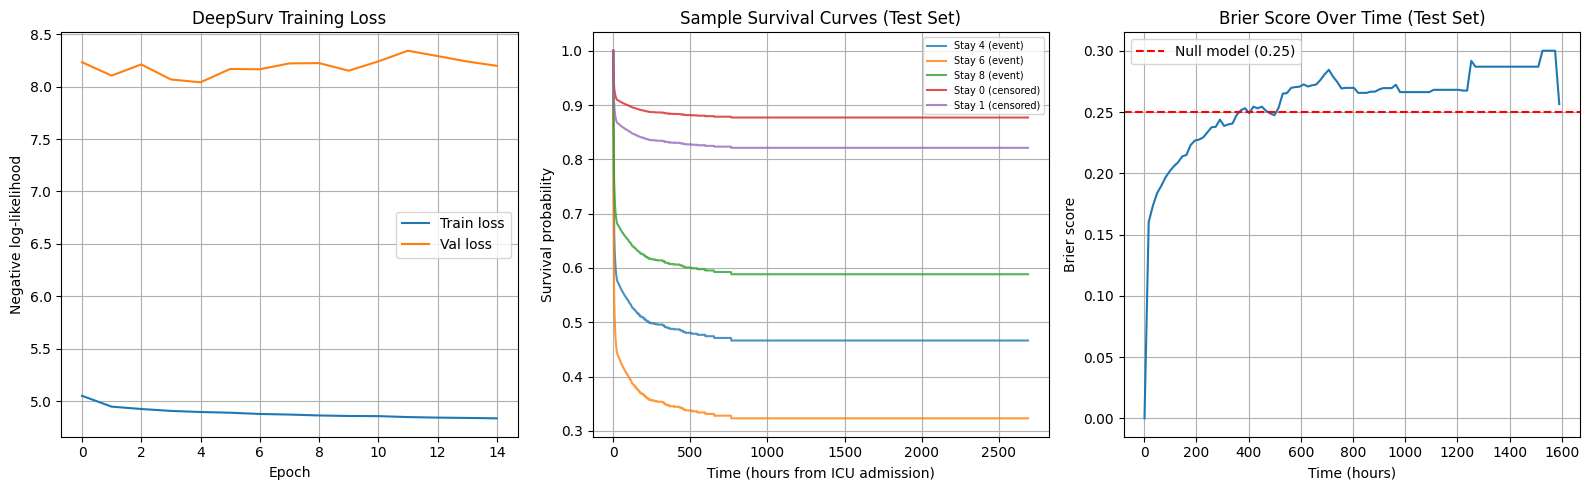

Plot saved to Drive ✓


In [8]:
# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Training loss curves
log_df = log.to_pandas()
axes[0].plot(log_df['train_loss'], label='Train loss')
axes[0].plot(log_df['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Negative log-likelihood')
axes[0].set_title('DeepSurv Training Loss')
axes[0].legend()
axes[0].grid(True)

# 2. Sample survival curves (test set)
n_samples = min(5, X_test.shape[0])
event_idx  = np.where(events_test == 1)[0][:3]
censor_idx = np.where(events_test == 0)[0][:2]
sample_idx = np.concatenate([event_idx, censor_idx])

for idx in sample_idx:
    label = f"Stay {idx} ({'event' if events_test[idx]==1 else 'censored'})"
    axes[1].plot(surv_test.iloc[:, idx], label=label, alpha=0.8)
axes[1].set_xlabel('Time (hours from ICU admission)')
axes[1].set_ylabel('Survival probability')
axes[1].set_title('Sample Survival Curves (Test Set)')
axes[1].legend(fontsize=7)
axes[1].grid(True)

# 3. Brier score over time
brier_scores = ev_test.brier_score(time_grid_test)
axes[2].plot(time_grid_test, brier_scores)
axes[2].axhline(0.25, color='red', linestyle='--', label='Null model (0.25)')
axes[2].set_xlabel('Time (hours)')
axes[2].set_ylabel('Brier score')
axes[2].set_title('Brier Score Over Time (Test Set)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'deepsurv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to Drive ✓")

In [18]:
# ── Cell A: Imports & evaluation function ─────────────────────────────────────
from sklearn.metrics import (
    precision_recall_curve, auc, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    roc_auc_score
)
from sklearn.calibration import calibration_curve
import numpy as np
import matplotlib.pyplot as plt

time_points = surv_test.index.values.astype(float)

def evaluate_at_horizon(horizon_h, label=''):
    horizon_idx = np.argmin(np.abs(time_points - horizon_h))
    actual_t    = time_points[horizon_idx]
    surv_prob   = surv_test.iloc[horizon_idx, :].values
    risk        = 1.0 - surv_prob

    y_true = (
        (test_df['event'].values == 1) &
        (test_df['duration'].values <= horizon_h)
    ).astype(int)

    if y_true.sum() == 0:
        print(f"  [{label}] No positives at horizon {horizon_h}h — skipping.")
        return None

    thresholds = np.arange(0.01, 0.99, 0.005)
    f1_scores  = [f1_score(y_true, (risk >= t).astype(int), zero_division=0)
                  for t in thresholds]
    best_thresh = thresholds[np.argmax(f1_scores)]
    y_pred      = (risk >= best_thresh).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision_c, recall_c, _ = precision_recall_curve(y_true, risk)
    auprc = auc(recall_c, precision_c)
    auroc = roc_auc_score(y_true, risk)

    neg_r, pos_r = [], []
    for t in thresholds:
        yp  = (risk >= t).astype(int)
        _tn = ((yp==0) & (y_true==0)).sum()
        _fp = ((yp==1) & (y_true==0)).sum()
        _fn = ((yp==0) & (y_true==1)).sum()
        _tp = ((yp==1) & (y_true==1)).sum()
        neg_r.append(_tn / (_tn+_fp) if (_tn+_fp) > 0 else 0)
        pos_r.append(_tp / (_tp+_fn) if (_tp+_fn) > 0 else 0)
    aunrc = auc(pos_r, neg_r)

    spec  = tn/(tn+fp) if (tn+fp) > 0 else 0
    far   = fp/(fp+tn) if (fp+tn) > 0 else 0
    npv   = tn/(tn+fn) if (tn+fn) > 0 else 0
    mcc   = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    brier = brier_score_loss(y_true, risk)
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    f1v   = f1_score(y_true, y_pred, zero_division=0)

    return dict(
        horizon=horizon_h, actual_t=actual_t,
        threshold=best_thresh,
        tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
        accuracy=round(acc,4), precision=round(prec,4),
        recall=round(rec,4), specificity=round(spec,4),
        f1=round(f1v,4), mcc=round(mcc,4), kappa=round(kappa,4),
        false_alarm_rate=round(far,4), npv=round(npv,4),
        auroc=round(auroc,4), auprc=round(auprc,4),
        aunrc=round(aunrc,4), c_index=round(c_test,4),
        brier=round(brier,4),
        y_true=y_true, risk=risk,
        precision_curve=precision_c, recall_curve=recall_c,
        neg_recalls=neg_r, pos_recalls=pos_r,
        thresholds=thresholds, f1_scores=f1_scores,
    )

print("evaluate_at_horizon defined ✓")

evaluate_at_horizon defined ✓


In [19]:
# ── Cell B: Run evaluations at 3 horizons ─────────────────────────────────────
results_6h  = evaluate_at_horizon(6,  label='6h')
results_24h = evaluate_at_horizon(24, label='24h')
results_48h = evaluate_at_horizon(48, label='48h')

print(f"\nFull-stay event rate : {test_df['event'].mean():.2%} "
      f"({test_df['event'].sum():,} / {len(test_df):,})")
print(f"C-Index (td)         : {c_test:.4f}")


Full-stay event rate : 33.15% (3,912 / 11,800)
C-Index (td)         : 0.7544


In [20]:
# ── Cell C: Print metrics for all horizons ────────────────────────────────────
for res, label in [
    (results_6h,  '6h Horizon'),
    (results_24h, '24h Horizon'),
    (results_48h, '48h Horizon'),
]:
    if res is None:
        continue
    print(f"\n{'='*57}")
    print(f"  DeepSurv — {label}  "
          f"(t≈{res['actual_t']:.1f}h | threshold={res['threshold']:.3f})")
    print(f"  Positives: {res['y_true'].sum():,} / {len(res['y_true']):,} "
          f"({res['y_true'].mean():.2%})")
    print(f"{'='*57}")
    print(f"  Confusion Matrix : TN={res['tn']:,}  FP={res['fp']:,}  "
          f"FN={res['fn']:,}  TP={res['tp']:,}")
    print(f"  Accuracy         : {res['accuracy']:.4f}")
    print(f"  Precision        : {res['precision']:.4f}")
    print(f"  Recall (Sens.)   : {res['recall']:.4f}")
    print(f"  Specificity      : {res['specificity']:.4f}")
    print(f"  F1-Score         : {res['f1']:.4f}")
    print(f"  MCC              : {res['mcc']:.4f}")
    print(f"  Cohen's Kappa    : {res['kappa']:.4f}")
    print(f"  False Alarm Rate : {res['false_alarm_rate']:.4f}")
    print(f"  NPV              : {res['npv']:.4f}")
    print(f"  AUROC            : {res['auroc']:.4f}")
    print(f"  AUPRC            : {res['auprc']:.4f}")
    print(f"  AUNRC            : {res['aunrc']:.4f}")
    print(f"  C-Index (td)     : {res['c_index']:.4f}")
    print(f"  Brier Score      : {res['brier']:.4f}")
    print(f"{'='*57}")


  DeepSurv — 6h Horizon  (t≈6.0h | threshold=0.305)
  Positives: 2,859 / 11,800 (24.23%)
  Confusion Matrix : TN=6,592  FP=2,349  FN=803  TP=2,056
  Accuracy         : 0.7329
  Precision        : 0.4667
  Recall (Sens.)   : 0.7191
  Specificity      : 0.7373
  F1-Score         : 0.5661
  MCC              : 0.4043
  Cohen's Kappa    : 0.3855
  False Alarm Rate : 0.2627
  NPV              : 0.8914
  AUROC            : 0.8062
  AUPRC            : 0.5625
  AUNRC            : 0.8061
  C-Index (td)     : 0.7544
  Brier Score      : 0.1441

  DeepSurv — 24h Horizon  (t≈24.0h | threshold=0.350)
  Positives: 3,677 / 11,800 (31.16%)
  Confusion Matrix : TN=5,560  FP=2,563  FN=776  TP=2,901
  Accuracy         : 0.7170
  Precision        : 0.5309
  Recall (Sens.)   : 0.7890
  Specificity      : 0.6845
  F1-Score         : 0.6347
  MCC              : 0.4397
  Cohen's Kappa    : 0.4179
  False Alarm Rate : 0.3155
  NPV              : 0.8775
  AUROC            : 0.8128
  AUPRC            : 0.6404
  

surv_test shape (time_points x stays): (46432, 11800)
test_df shape: (11800, 9)
y_true_binary positives: 3677
y_true_binary total: 11800
risk_score shape: (11800,)

test_df event distribution:


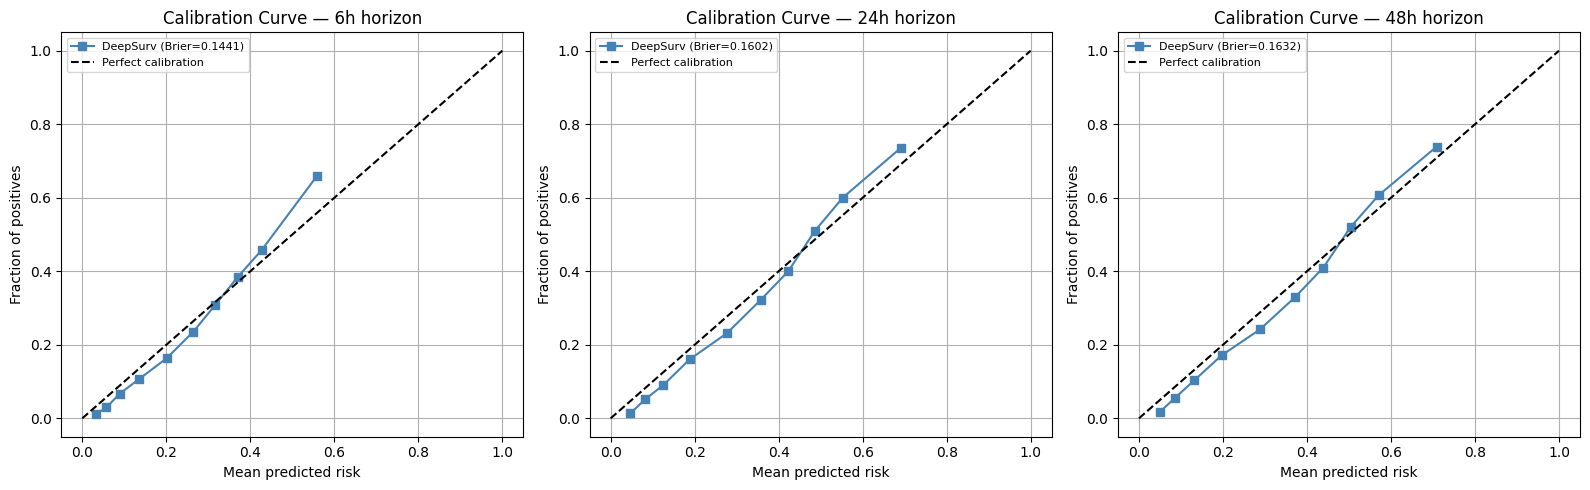

event
0    7888
1    3912
Name: count, dtype: int64

test_df duration stats:
count    11800.000000
mean        47.355799
std         76.329806
min          1.002500
25%          6.539722
50%         26.777917
75%         54.589028
max       1590.416111
Name: duration, dtype: float64

How many events fall within 24h horizon:
3677

How many events fall AFTER 24h:
235

time_points range in surv_test:
min=1.00h  max=2689.22h


In [21]:
print("surv_test shape (time_points x stays):", surv_test.shape)
print("test_df shape:", test_df.shape)
print("y_true_binary positives:", y_true_binary.sum())
print("y_true_binary total:", len(y_true_binary))
print("risk_score shape:", risk_score.shape)

print("\ntest_df event distribution:")# ── Cell D: Calibration curves for all horizons ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (res, label) in enumerate([
    (results_6h,  '6h'),
    (results_24h, '24h'),
    (results_48h, '48h'),
]):
    if res is None:
        axes[i].set_visible(False)
        continue

    frac_pos, mean_pred = calibration_curve(
        res['y_true'], res['risk'], n_bins=10, strategy='quantile'
    )
    axes[i].plot(mean_pred, frac_pos, 's-', color='steelblue',
                 label=f"DeepSurv (Brier={res['brier']:.4f})")
    axes[i].plot([0,1], [0,1], 'k--', label='Perfect calibration')
    axes[i].set_xlabel('Mean predicted risk')
    axes[i].set_ylabel('Fraction of positives')
    axes[i].set_title(f'Calibration Curve — {label} horizon')
    axes[i].legend(fontsize=8)
    axes[i].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'deepsurv_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print(test_df['event'].value_counts())

print("\ntest_df duration stats:")
print(test_df['duration'].describe())

print("\nHow many events fall within 24h horizon:")
print(((test_df['event']==1) & (test_df['duration'] <= 24)).sum())

print("\nHow many events fall AFTER 24h:")
print(((test_df['event']==1) & (test_df['duration'] > 24)).sum())

print("\ntime_points range in surv_test:")
print(f"min={surv_test.index.min():.2f}h  max={surv_test.index.max():.2f}h")

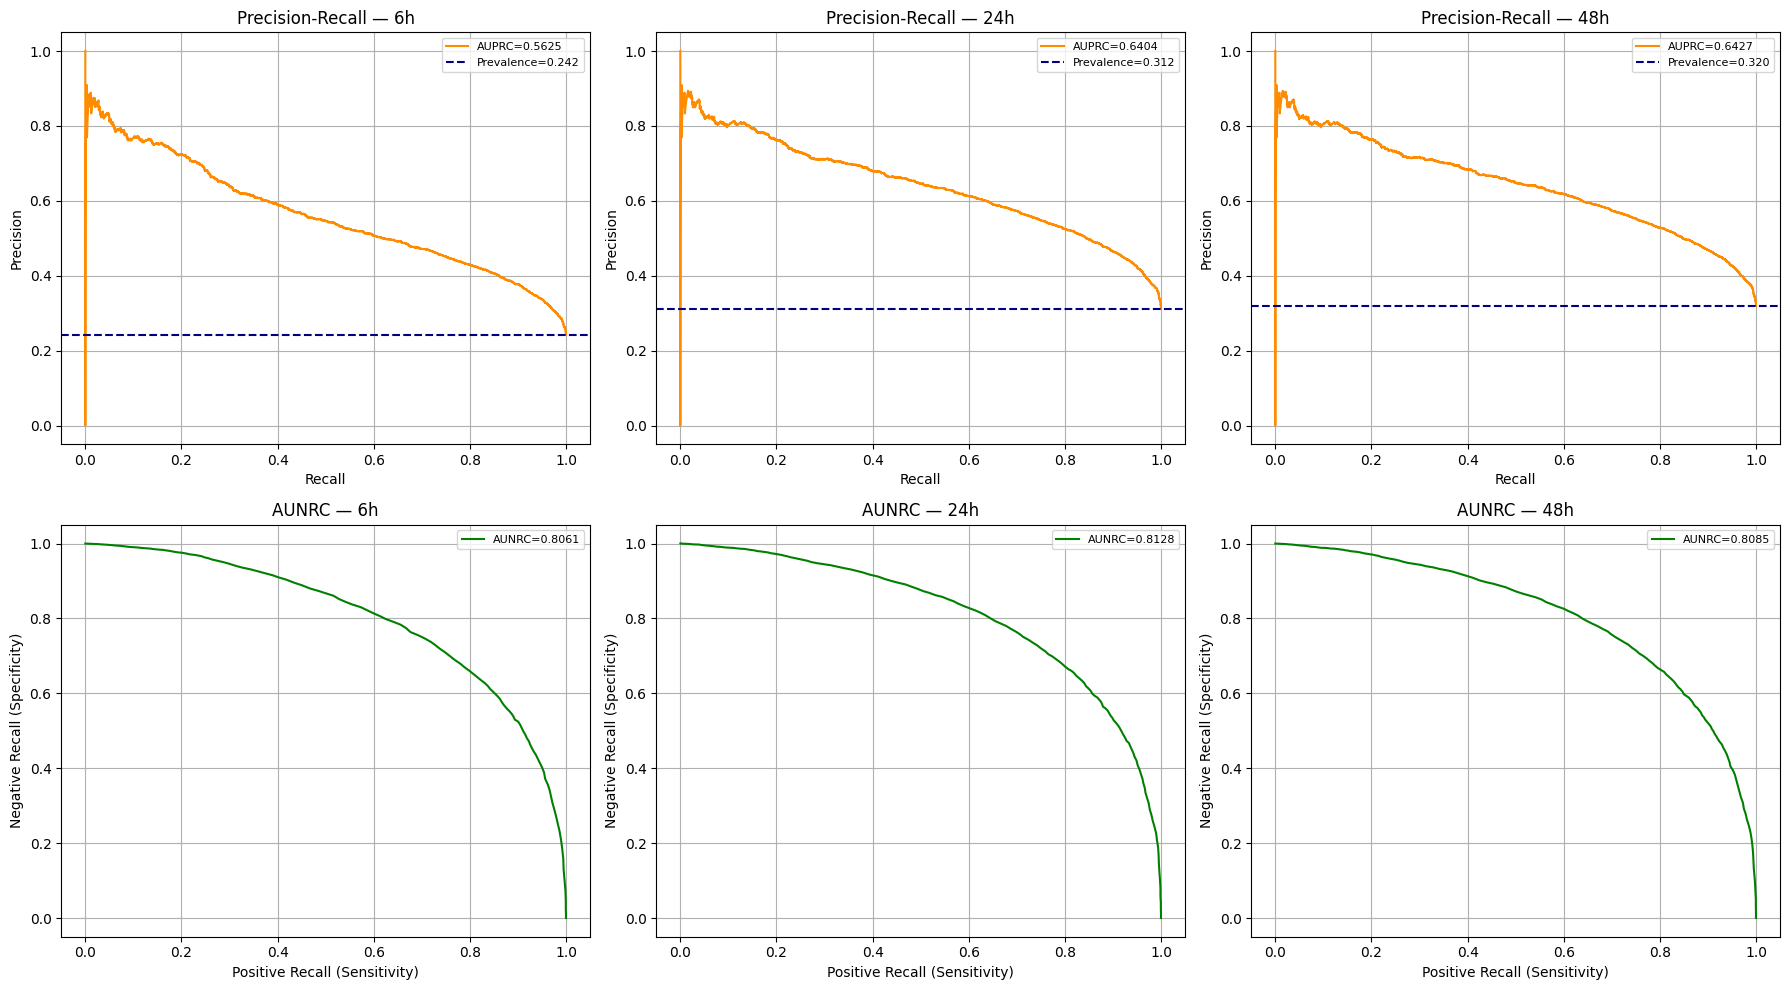

In [22]:
# ── Cell E: Multi-horizon curves ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (res, label) in enumerate([
    (results_6h,  '6h'),
    (results_24h, '24h'),
    (results_48h, '48h'),
]):
    if res is None:
        for row in range(2):
            axes[row, i].set_visible(False)
        continue

    # Row 0: Precision-Recall curve
    axes[0, i].plot(res['recall_curve'], res['precision_curve'],
                    color='darkorange', label=f"AUPRC={res['auprc']:.4f}")
    axes[0, i].axhline(res['y_true'].mean(), color='navy', linestyle='--',
                       label=f"Prevalence={res['y_true'].mean():.3f}")
    axes[0, i].set_title(f'Precision-Recall — {label}')
    axes[0, i].set_xlabel('Recall')
    axes[0, i].set_ylabel('Precision')
    axes[0, i].legend(fontsize=8)
    axes[0, i].grid(True)

    # Row 1: AUNRC — neg recall vs pos recall
    axes[1, i].plot(res['pos_recalls'], res['neg_recalls'],
                    color='green', label=f"AUNRC={res['aunrc']:.4f}")
    axes[1, i].set_title(f'AUNRC — {label}')
    axes[1, i].set_xlabel('Positive Recall (Sensitivity)')
    axes[1, i].set_ylabel('Negative Recall (Specificity)')
    axes[1, i].legend(fontsize=8)
    axes[1, i].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'deepsurv_curves.png', dpi=150, bbox_inches='tight')
plt.show()

  Early Detection Gain  (24h horizon, True Positives)
  True positives detected      : 2,901
  Median onset hour            : 3.1h from ICU admission
  Mean onset hour              : 4.4h from ICU admission
  Median lead time vs onset    : 0.0h
  Mean lead time vs onset      : 0.0h


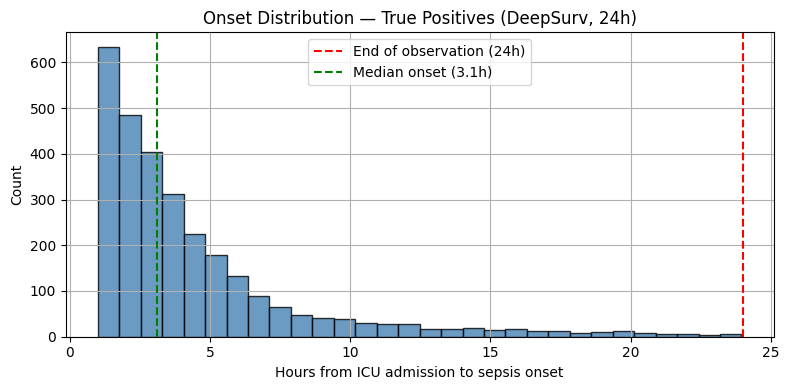

In [23]:
# ── Cell F: Early Detection Gain ──────────────────────────────────────────────
# Uses 24h horizon results as the primary evaluation point

res = results_24h
if res is not None:
    test_eval = test_df.copy().reset_index(drop=True)
    test_eval['risk_score'] = res['risk']
    test_eval['y_pred']     = (res['risk'] >= res['threshold']).astype(int)
    test_eval['y_true']     = res['y_true']

    tp_mask = (
        (test_eval['y_pred'] == 1) &
        (test_eval['y_true'] == 1)
    )
    tp_stays = test_eval[tp_mask].copy()

    if len(tp_stays) > 0:
        # Lead time: how far before onset does the model alert
        # Observation window = 24h; alert fires at end of window
        # Lead time = onset_hour - 24  (clipped at 0 for onsets within window)
        tp_stays['lead_time_hours'] = (tp_stays['duration'] - 24.0).clip(lower=0)

        median_onset = tp_stays['duration'].median()
        mean_onset   = tp_stays['duration'].mean()
        median_lead  = tp_stays['lead_time_hours'].median()
        mean_lead    = tp_stays['lead_time_hours'].mean()

        print("=" * 55)
        print("  Early Detection Gain  (24h horizon, True Positives)")
        print("=" * 55)
        print(f"  True positives detected      : {len(tp_stays):,}")
        print(f"  Median onset hour            : {median_onset:.1f}h from ICU admission")
        print(f"  Mean onset hour              : {mean_onset:.1f}h from ICU admission")
        print(f"  Median lead time vs onset    : {median_lead:.1f}h")
        print(f"  Mean lead time vs onset      : {mean_lead:.1f}h")
        print("=" * 55)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(tp_stays['duration'], bins=30, edgecolor='black',
                color='steelblue', alpha=0.8)
        ax.axvline(24, color='red', linestyle='--',
                   label='End of observation (24h)')
        ax.axvline(median_onset, color='green', linestyle='--',
                   label=f'Median onset ({median_onset:.1f}h)')
        ax.set_xlabel('Hours from ICU admission to sepsis onset')
        ax.set_ylabel('Count')
        ax.set_title('Onset Distribution — True Positives (DeepSurv, 24h)')
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'deepsurv_early_detection.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("No true positives at this threshold.")
        median_onset = mean_onset = median_lead = mean_lead = None